# Simple Pendulum

The simple pendulum is a classical example of a nonlinear dynamical system and plays an important role in mechanics, oscillation theory, and numerical analysis. Unlike free fall problems, the pendulum exhibits periodic motion governed by a nonlinear restoring force.

The equation of motion for a simple pendulum is given by

$$
\frac{d^2\theta}{dt^2} + \frac{g}{L}\sin\theta = 0
$$

where:
- theta is the angular displacement,
- g  is the acceleration due to gravity,
- L  is the length of the pendulum.

Since this is a second-order nonlinear ordinary differential equation, it is converted into a system of first-order equations before applying numerical methods such as Euler, RK4, and RK5.

By defining the angular velocity as

$$
\omega = \frac{d\theta}{dt}
$$

the system becomes

$$
\frac{d\theta}{dt} = \omega
$$

$$
\frac{d\omega}{dt} = -\frac{g}{L}\sin\theta
$$

In this section, numerical methods are used to study the oscillatory behavior of the pendulum, visualize phase-space dynamics, and analyze how well different solvers preserve the system's energy over time.

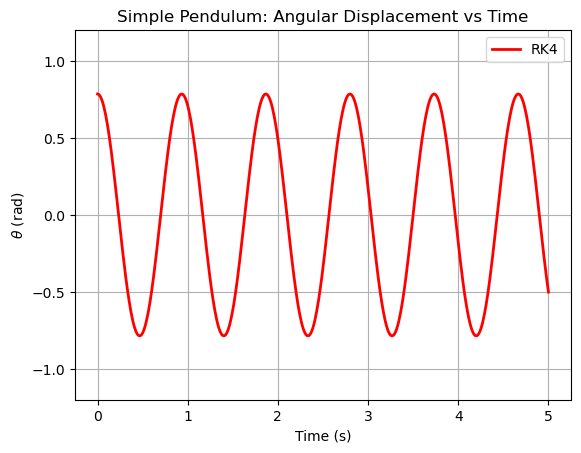

In [31]:
# splitting the equation as dw/dt = -g/l  sin0 as where w = d0/dt

import sys
import os
sys.path.append("../src")
from rkmethods import rk4
import numpy as np
import matplotlib.pyplot as plt

# pendulum function

def f(t,y):
    theta,omega = y  

    return np.array([omega,-(g/L)*np.sin(theta)])

g = 9.81
L = 0.2
theta0 = np.pi/4 # initial position
omega0 = 0 # initial velocity
y0 = np.array([theta0,omega0])  #  starting point
t0 = 0
h = 0.01
n = 500

t, y = rk4(f, t0, y0, n, h)

theta,omega = y[:,0],y[:,1]  

plt.plot(t, theta, 'r', label='RK4',linewidth=2)

plt.xlabel("Time (s)")
plt.ylabel(r"$\theta$ (rad)")
plt.title("Simple Pendulum: Angular Displacement vs Time")
plt.legend()
plt.ylim(-1.2, 1.2)
plt.grid()
plt.show()



Now lets also plot phase plot 

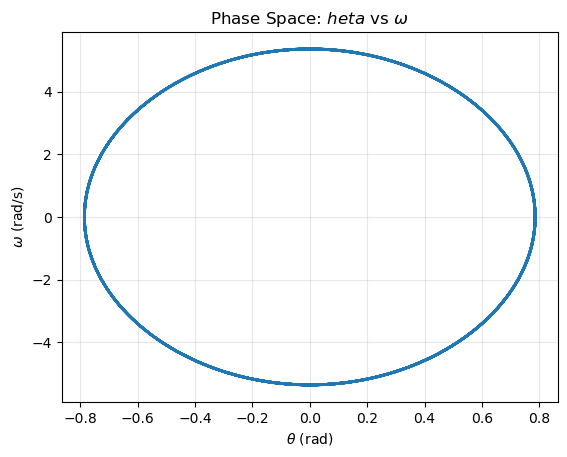

In [ ]:

plt.plot(theta, omega)
plt.xlabel(r"$\theta$ (rad)")
plt.ylabel(r"$\omega$ (rad/s)")
plt.title("Phase Space: $\theta$ vs $\omega$ ")
plt.grid(alpha=0.3)
plt.show()

The phase-space trajectory forms a closed loop, indicating periodic motion and approximate conservation of energy. For small angular displacements, the trajectory is nearly elliptical, reflecting behavior similar to a simple harmonic oscillator. At larger angles, nonlinear effects become more prominent due to the sine term in the equation of motion.

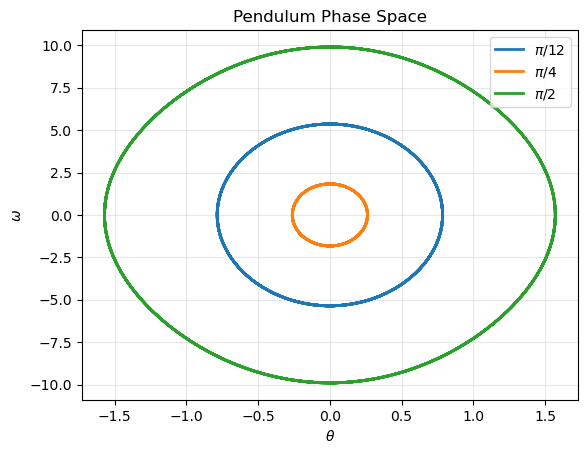

In [33]:
g = 9.81
L = 0.2
theta0 = [np.pi/4,np.pi/12,np.pi/2] 
omega0 = 0 

t0 = 0
h = 0.01
n = 500

labels = [r"$\pi/12$", r"$\pi/4$", r"$\pi/2$"] # for good plot labels(AI) 
for th,lab in zip(theta0,labels):
    y0 = np.array([th, omega0])
    t, y = rk4(f, t0, y0, n, h)
    theta = y[:,0]
    omega = y[:,1]
    plt.plot(theta, omega, label=lab)
   


plt.xlabel(r"$\theta$")
plt.ylabel(r"$\omega$")
plt.title("Pendulum Phase Space")
plt.legend()
plt.grid(alpha=0.3)

For small angular displacements, the phase-space trajectory is nearly elliptical, corresponding to simple harmonic motion. As the initial angle increases, nonlinear effects become more significant, causing visible distortion in the phase trajectory.

## Energy Conservation in the Pendulum System

An important property of the ideal simple pendulum is the conservation of mechanical energy. In the absence of damping or external forces, the total energy of the system remains constant throughout the motion, while continuously transforming between kinetic and potential energy.

For the pendulum system, the total mechanical energy is given by

$$
E = \frac{1}{2}mL^2\omega^2 + mgL(1-\cos\theta)
$$

where:
- m is the mass of the pendulum bob,
- L is the pendulum length,
- omega is the angular velocity,
- $\theta$ is the angular displacement.

Since the analytical solution of the nonlinear pendulum is difficult to obtain in general, energy conservation provides an important way to evaluate the quality of numerical methods. A good numerical solver should preserve the total energy of the system with minimal numerical drift over time.

In this section, the Euler, RK4, and RK5 methods are compared based on how well they conserve the pendulum’s mechanical energy during the simulation.

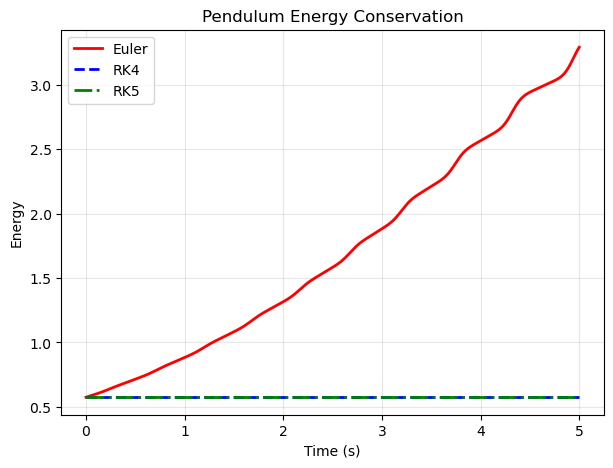

In [34]:
from euler import EulerODE
from rkmethods import rk5

m= 1 # standard mass
g = 9.81
L = 0.2
theta0 = np.pi/4 # initial position
omega0 = 0 # initial velocity
y0 = np.array([theta0,omega0])  #  starting point
t0 = 0
h = 0.01
n = 500

t1, y1 = EulerODE(f, t0, y0, n, h)
t2, y2 = rk4(f, t0, y0, n, h)
t3, y3 = rk5(f, t0, y0, n, h)

theta1,omega1 = y1[:,0],y1[:,1] 
theta2,omega2 = y2[:,0],y2[:,1] 
theta3,omega3 = y3[:,0],y3[:,1] 

E1 = 0.5*m*(L**2)*(omega1**2) + m*g*L*(1 - np.cos(theta1))
E2 = 0.5*m*(L**2)*(omega2**2) + m*g*L*(1 - np.cos(theta2))
E3 = 0.5*m*(L**2)*(omega3**2) + m*g*L*(1 - np.cos(theta3))
plt.figure(figsize=(7,5))

plt.plot(t1, E1,color='red',linewidth=2,label='Euler')

plt.plot(t2, E2,color='blue',linestyle='--',linewidth=2,label='RK4')

plt.plot(t3, E3,color='green',linestyle='-.',linewidth=2,label='RK5')

plt.xlabel("Time (s)")
plt.ylabel("Energy")
plt.title("Pendulum Energy Conservation")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

Here, it can be observed that the RK4 and RK5 methods conserve energy very well, with only minimal numerical variation over time. 
In the  case Euler method, it  also approximately conserves energy, but its numerical drift is significantly larger compared to RK4 and RK5. Due to this larger error scale, plotting all methods together on a normal scale can make the differences between RK4 and RK5 difficult to visualize clearly.

So, an energy error plot on a logarithmic scale provides a better comparison of the numerical accuracy and energy conservation properties of the different methods.

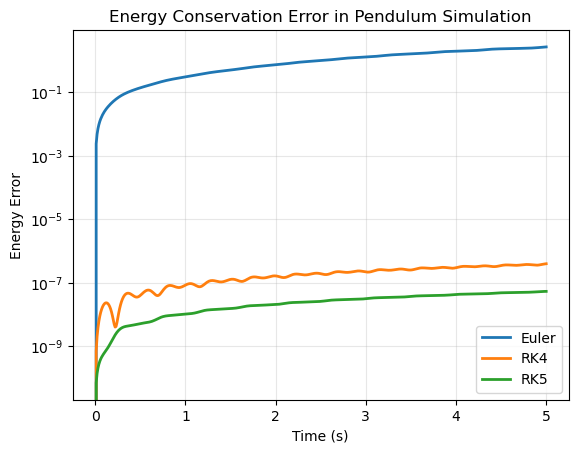

In [35]:
#the energy deviation from the initial value is plotted 

error1 = np.abs(E1 - E1[0])
error2 = np.abs(E2 - E2[0])
error3 = np.abs(E3 - E3[0])
plt.plot(t1, error1, label="Euler")
plt.plot(t2, error2, label="RK4")
plt.plot(t3, error3, label="RK5")
plt.yscale("log")

plt.xlabel("Time (s)")
plt.ylabel("Energy Error")
plt.title("Energy Conservation Error in Pendulum Simulation")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

We can see that the  energy error analysis shows how different numerical methods affect the conservation of energy in the pendulum system. Even small numerical errors can accumulate over time and influence the energy conservation behavior of the simulation.
From this results, RK4 and RK5 preserve the total energy much more accurately, while the Euler method introduces comparatively larger numerical drift. This demonstrates the importance of higher-order numerical methods in accurately simulating conservative dynamical systems.

## Small angle analytical comparison
For small angular displacements, the approximation

$$
\sin\theta \approx \theta
$$

can be used. Under this approximation, the nonlinear pendulum equation reduces to the linear simple harmonic motion equation. This allows an analytical solution to be obtained and compared with the numerical results.

By comparing the analytical and numerical solutions for small angles, we can verify the accuracy of the implemented numerical methods and observe how the pendulum behaves approximately as a simple harmonic oscillator in the small-angle regime.

The analytical solution of this equation is

$$
\theta(t) = \theta_0 \cos\left(\sqrt{\frac{g}{L}}\,t\right)
$$


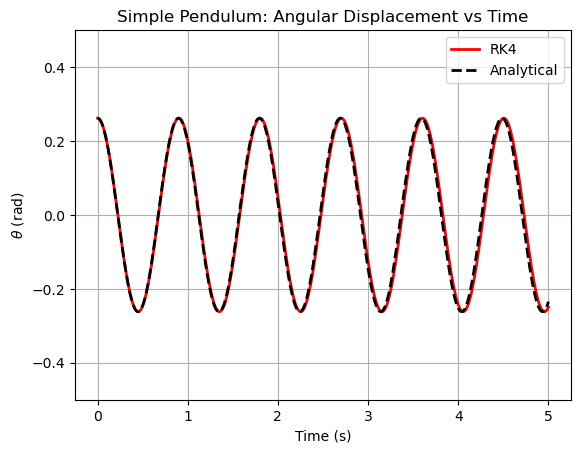

In [36]:
g = 9.81
L = 0.2
theta0 = np.pi/12 # small angle 
omega0 = 0 
y0 = np.array([theta0,omega0])  
t0 = 0
h = 0.01
n = 500

t, y = rk4(f, t0, y0, n, h)

theta,omega = y[:,0],y[:,1]  

#analytical value
theta_exact = theta0 * np.cos(np.sqrt(g/L) * t)

plt.plot(t, theta, color='red', linewidth=2, label='RK4')
plt.plot(t, theta_exact, color='black', linestyle='--',linewidth=2, label='Analytical')


plt.xlabel("Time (s)")
plt.ylabel(r"$\theta$ (rad)")
plt.ylim(-0.5, 0.5)
plt.title("Simple Pendulum: Angular Displacement vs Time")
plt.legend()
plt.grid()
plt.show()



For small angular displacements, the numerical RK4 solution closely matches the analytical small-angle solution. This verifies both the correctness of the numerical implementation and the validity of the small-angle approximation for small oscillations.


## Conclusion

In this study, ordinary differential equation solvers were successfully used to simulate the motion of a simple pendulum. The nonlinear pendulum equation was converted into a system of first-order equations and solved numerically using Euler, RK4, and RK5 methods.

The simulations helped visualize the oscillatory behavior of the pendulum through angular displacement plots, phase-space trajectories, and energy analysis. Energy conservation was also studied to evaluate the accuracy and stability of different numerical methods.

From the results, higher-order methods such as RK4 and RK5 were found to preserve energy much more accurately compared to the Euler method. This demonstrates how the choice of numerical solver can significantly affect the accuracy and physical reliability of simulations.

Overall, this study highlights both the usefulness and the limitations of numerical methods in solving nonlinear dynamical systems, where exact analytical solutions may not always be easily obtainable.